In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv("data/IMDB Dataset.csv")
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [3]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
df_positive = df[df["sentiment"] == "positive"][:10000]
df_negative = df[df["sentiment"] == "negative"][:8000]

In [5]:
df_subset = pd.concat([df_positive, df_negative], ignore_index=True)

In [6]:
df_subset["sentiment"].unique()

<StringArray>
['positive', 'negative']
Length: 2, dtype: str

In [7]:
df_subset["sentiment"] = df_subset["sentiment"].replace({"positive": 1, "negative": -1})
df_subset.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1


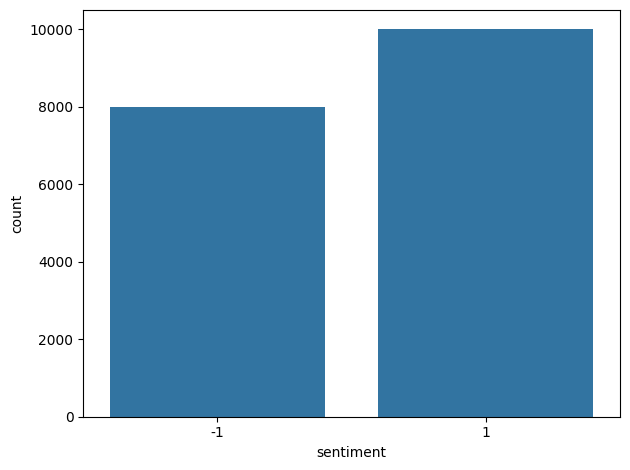

In [8]:
sns.countplot(data=df_subset, x="sentiment")
plt.tight_layout()
plt.show()

### Split Data to Train and Test Sets

In [9]:
y = df_subset["sentiment"]
X = df_subset['review']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.3, random_state=42)

y_train = y_train.squeeze().astype(int)
y_test = y_test.squeeze().astype(int)

### TF-IDF Vectorization

In [10]:
tfidf = TfidfVectorizer(stop_words="english")

X_train_vect = tfidf.fit_transform(X_train) 
X_test_vect  = tfidf.transform(X_test)

### Models
#### Training

In [11]:
svc = SVC(kernel="linear")
rf = RandomForestClassifier()
nb = GaussianNB()

svc.fit(X_train_vect, y_train)
rf.fit(X_train_vect, y_train)
nb.fit(X_train_vect.toarray(), y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


#### Testing

In [12]:
y_pred_svc = svc.predict(X_test_vect)
y_pred_rf = rf.predict(X_test_vect)
y_pred_nb = nb.predict(X_test_vect.toarray())

### Evaluation Metrics

In [21]:
models = {
    "SVC": y_pred_svc,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb
}

results = []

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
    })
    print(f"Confusion Matrix for {name}:\n", confusion_matrix(y_test, y_pred))

df = pd.DataFrame(results)
df

Confusion Matrix for SVC:
 [[2000  376]
 [ 254 2770]]
Confusion Matrix for Random Forest:
 [[1807  569]
 [ 294 2730]]
Confusion Matrix for Naive Bayes:
 [[1599  777]
 [1211 1813]]


,Model,Accuracy,Precision,Recall,F1 Score
0,SVC,0.883333,0.883488,0.883333,0.882950
1,Random Forest,0.840185,0.841842,0.840185,0.838752
2,Naive Bayes,0.631852,0.642377,0.631852,0.633026
